Pearson correlation:
               price_lakh  area_sqft  rate_per_sqft  bhk_count
price_lakh          1.000      0.197          0.615      0.058
area_sqft           0.197      1.000         -0.001      0.010
rate_per_sqft       0.615     -0.001          1.000      0.007
bhk_count           0.058      0.010          0.007      1.000

Spearman correlation:
               price_lakh  area_sqft  rate_per_sqft  bhk_count
price_lakh          1.000      0.797          0.809      0.593
area_sqft           0.797      1.000          0.346      0.693
rate_per_sqft       0.809      0.346          1.000      0.300
bhk_count           0.593      0.693          0.300      1.000

Key relationships:
Area vs price (Pearson): 0.197
Area vs price (Spearman): 0.797
Area vs rate per sqft (Pearson): -0.001
Area vs rate per sqft (Spearman): 0.346
BHK vs price (Pearson): 0.058
BHK vs price (Spearman): 0.593


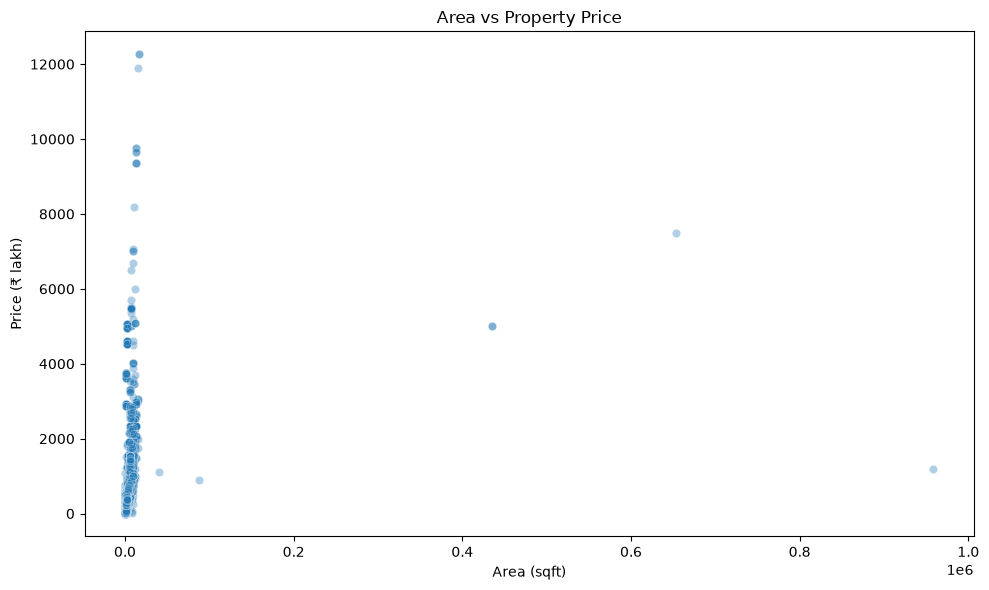

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

project_folder = Path.cwd()

if project_folder.name == "notebooks":
    project_folder = project_folder.parent

data_folder = project_folder / "data"
feature_file = data_folder / "propertylens_featured.csv"

df = pd.read_csv(feature_file)

# Select numeric variables relevant to price relationships
relationship_data = df[
    [
        "price_lakh",
        "area_sqft",
        "rate_per_sqft",
        "bhk_count"
    ]
].copy()

# Correlation matrices
pearson_corr = relationship_data.corr(method="pearson")
spearman_corr = relationship_data.corr(method="spearman")

print("Pearson correlation:")
print(pearson_corr.round(3).to_string())

print("\nSpearman correlation:")
print(spearman_corr.round(3).to_string())


# Key pairwise correlations
print("\nKey relationships:")

print(
    f"Area vs price (Pearson): "
    f"{pearson_corr.loc['area_sqft', 'price_lakh']:.3f}"
)

print(
    f"Area vs price (Spearman): "
    f"{spearman_corr.loc['area_sqft', 'price_lakh']:.3f}"
)

print(
    f"Area vs rate per sqft (Pearson): "
    f"{pearson_corr.loc['area_sqft', 'rate_per_sqft']:.3f}"
)

print(
    f"Area vs rate per sqft (Spearman): "
    f"{spearman_corr.loc['area_sqft', 'rate_per_sqft']:.3f}"
)

print(
    f"BHK vs price (Pearson): "
    f"{pearson_corr.loc['bhk_count', 'price_lakh']:.3f}"
)

print(
    f"BHK vs price (Spearman): "
    f"{spearman_corr.loc['bhk_count', 'price_lakh']:.3f}"
)


# Area vs price
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x="area_sqft",
    y="price_lakh",
    alpha=0.35
)

plt.xlabel("Area (sqft)")
plt.ylabel("Price (₹ lakh)")
plt.title("Area vs Property Price")
plt.tight_layout()
plt.show()